In [2]:
!mamba install rasterio

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, rasterio
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.716 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ __unix                        1.0.0                         hc286ada_0                    emscripten-forge              
+ affine                        2.4.0                         pyhd8ed1ab_1                  conda-forge                   
+ attrs                         26.1.0                        pyhcf101f3_0                  conda-forge                   
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ click                         8.3.2                         

In [3]:
import rasterio
import numpy as np 
from matplotlib import pyplot

In [4]:
def scale(band): # scale values for display purposes. May need adjusting as per your image. 
    return band / 200.0

In [8]:
# Load the blue layer given the folder and filename
my_raster_image = rasterio.open('raw_rasters/2025-06-28-00_00_2025-06-28-23_59_Sentinel-2_L2A_B02_(Raw).tif')
blue = scale(my_raster_image.read()[0])

# Load the green layer given the folder and filename
my_raster_image = rasterio.open('raw_rasters/2025-06-28-00_00_2025-06-28-23_59_Sentinel-2_L2A_B03_(Raw).tif')
green = scale(my_raster_image.read()[0])

# Load the red layer given the folder and filename
my_raster_image = rasterio.open('raw_rasters/2025-06-28-00_00_2025-06-28-23_59_Sentinel-2_L2A_B04_(Raw).tif')
red = scale(my_raster_image.read()[0])

# Load the nir layer given the folder and filename
my_raster_image = rasterio.open('raw_rasters/2025-06-28-00_00_2025-06-28-23_59_Sentinel-2_L2A_B08_(Raw).tif')
nir = scale(my_raster_image.read()[0])

/lib/python3.13/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [14]:
# Now we need to stack our layers into a single multi-dimensional numpy array
rgb = np.dstack((red, green, blue))
# Normalized Difference Vegetation Index
ndvi = (nir - red) / (nir + red)
# Based on McFeeters (1996)
ndwi = (green - nir) / (green + nir)

Text(0.5, 1.0, 'NDWI')

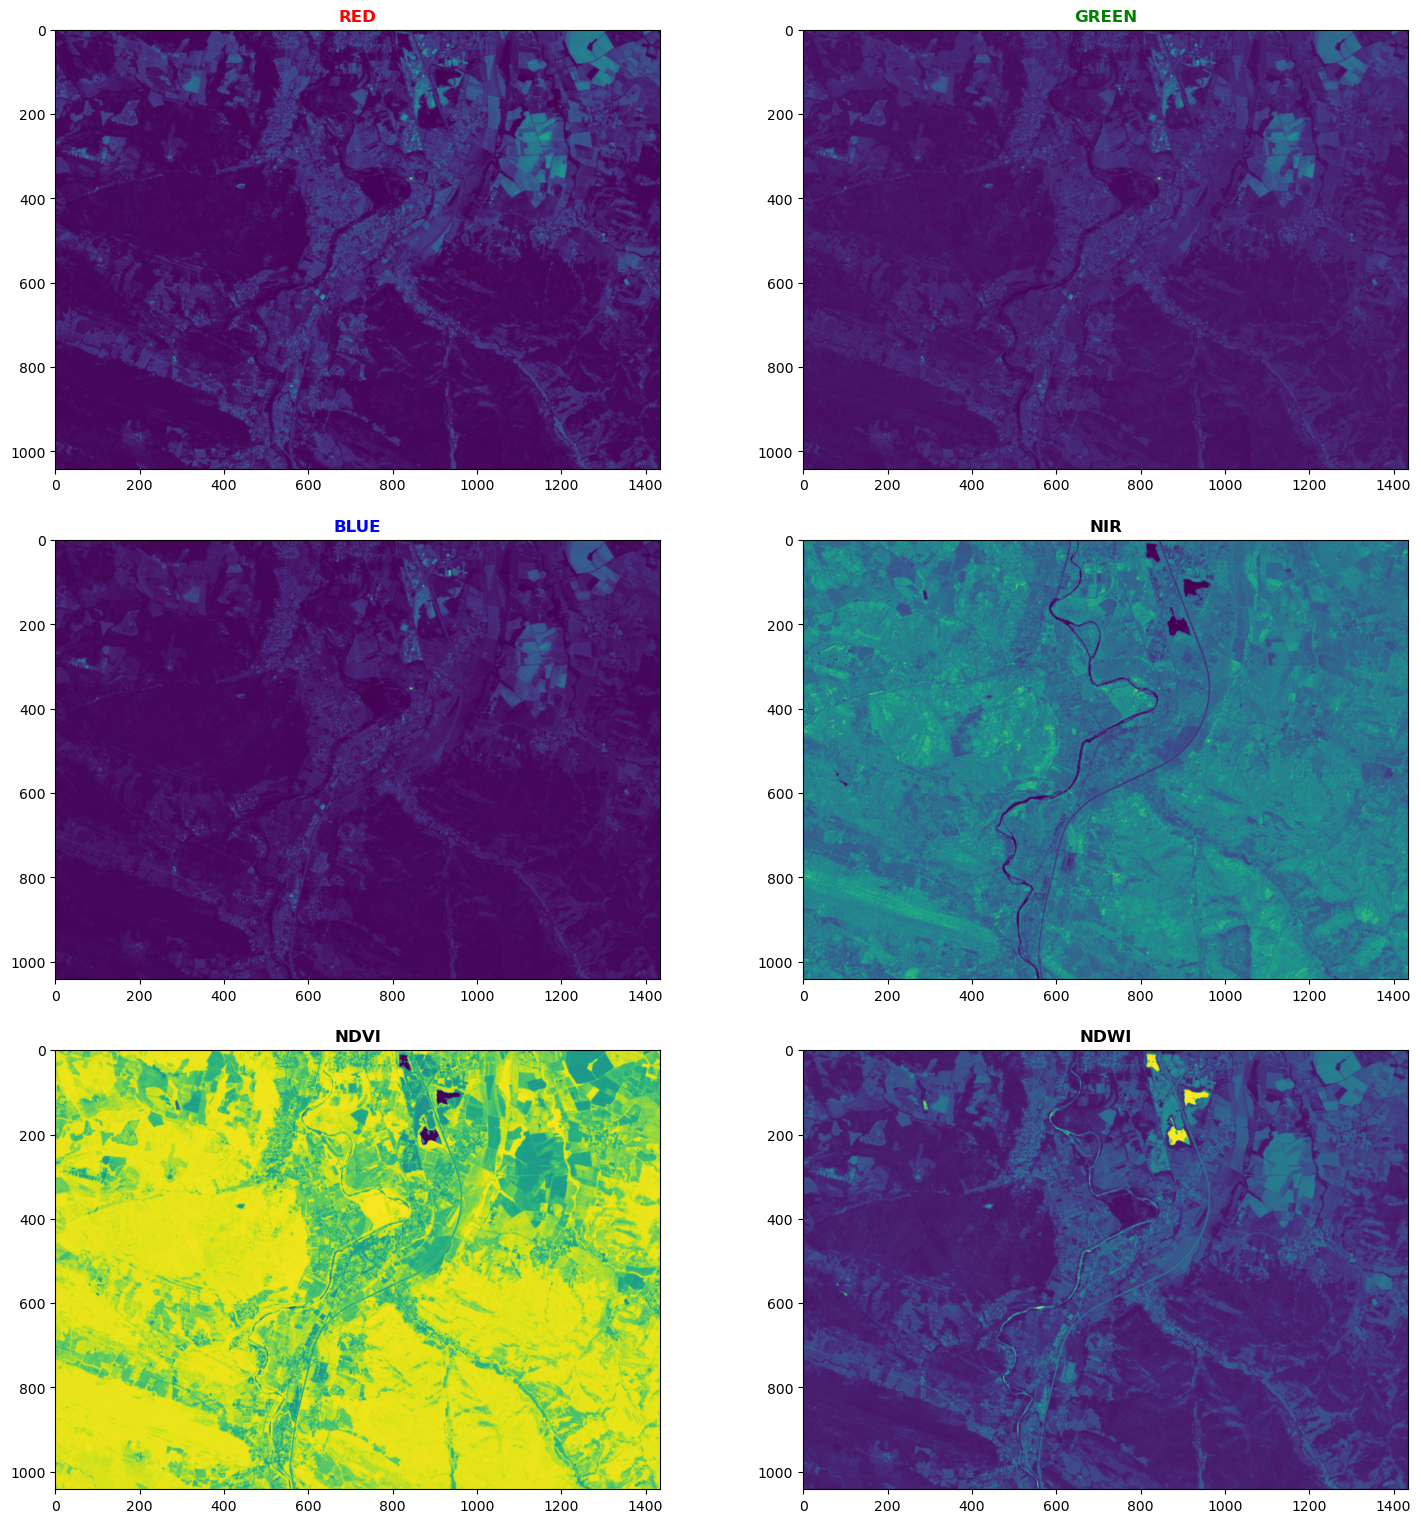

In [45]:
# pyplot.imshow(green)
fig, axs = pyplot.subplots(3, 2,figsize=(15, 15))
fig.tight_layout(pad=0.4, w_pad=0.5, h_pad=3)
axs[0, 0].imshow(red)
axs[0, 0].set_title("RED",fontweight="bold", color="red")
axs[0, 1].imshow(green)
axs[0, 1].set_title("GREEN",fontweight="bold", color="green")
axs[1, 0].imshow(blue)
axs[1, 0].set_title("BLUE",fontweight="bold", color="blue")
axs[1, 1].imshow(nir)
axs[1, 1].set_title("NIR",fontweight="bold")
axs[2, 0].imshow(ndvi)
axs[2, 0].set_title("NDVI",fontweight="bold")
axs[2, 1].imshow(ndwi)
axs[2, 1].set_title("NDWI",fontweight="bold")